In [36]:
from kagglehub import KaggleDatasetAdapter
import kagglehub

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "deepu1109/star-dataset",
    "6 class csv.csv"
)

print(df.head())

   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   

   Star type Star color Spectral Class  
0          0        Red              M  
1          0        Red              M  
2          0        Red              M  
3          0        Red              M  
4          0        Red              M  


In [4]:
df.columns

Index(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class'],
      dtype='str')

In [5]:
print("Star Type: ", df['Star type'].unique())
print("Star color: ", df['Star color'].unique())
print("Spectral Class: ", df['Spectral Class'].unique())

Star Type:  [0 1 2 3 4 5]
Star color:  <StringArray>
[               'Red',         'Blue White',              'White',
    'Yellowish White',         'Blue white', 'Pale yellow orange',
               'Blue',         'Blue-white',            'Whitish',
       'yellow-white',             'Orange',       'White-Yellow',
              'white',              'Blue ',          'yellowish',
          'Yellowish',         'Orange-Red',        'Blue white ',
         'Blue-White']
Length: 19, dtype: str
Spectral Class:  <StringArray>
['M', 'B', 'A', 'F', 'O', 'K', 'G']
Length: 7, dtype: str


In [6]:
df.isnull().sum()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [7]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


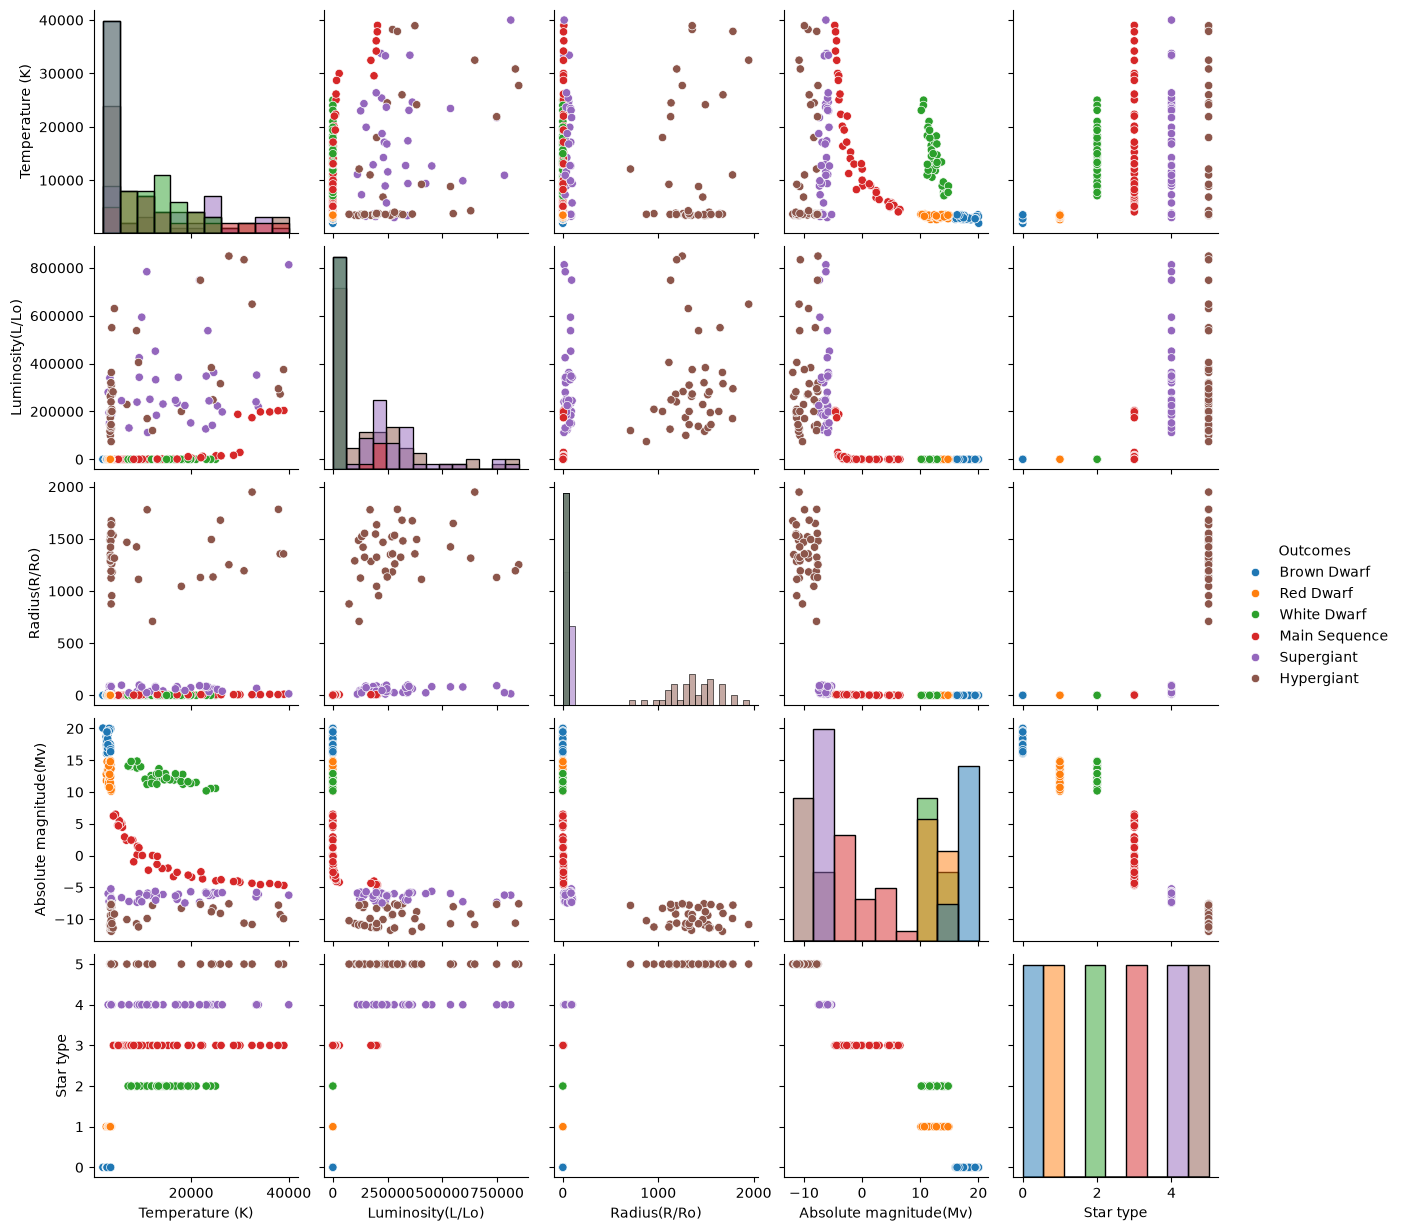

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df.copy()

star_type_names = {
    0: "Brown Dwarf",
    1: "Red Dwarf",
    2: "White Dwarf",
    3: "Main Sequence",
    4: "Supergiant",
    5: "Hypergiant"
}

df_plot["Outcomes"] = df_plot["Star type"].map(star_type_names)

sns.pairplot(
    df_plot,
    hue="Outcomes",
    diag_kind="hist"
)

plt.show()

In [9]:
import pandas as pd
df = pd.get_dummies(df, columns=['Star color'], dtype=int)
df = pd.get_dummies(df, columns=['Spectral Class'], dtype=int)

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Star type', axis=1)
y = df['Star type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [11]:
numeric_cols = [
    "Temperature (K)",
    "Luminosity(L/Lo)",
    "Radius(R/Ro)",
    "Absolute magnitude(Mv)"
]

In [12]:
from sklearn.preprocessing import MinMaxScaler

MN = MinMaxScaler()

X_train[numeric_cols] = MN.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = MN.transform(X_test[numeric_cols])

In [13]:
import torch
import torch.nn as nn 
import torch.nn.functional as F 

In [14]:
X_train = torch.tensor(X_train.to_numpy(dtype="float32"))
X_test = torch.tensor(X_test.to_numpy(dtype="float32"))

y_train = torch.tensor(y_train.to_numpy(dtype="int64"), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(dtype="int64"), dtype=torch.long)

In [15]:
torch.manual_seed(20)

In [16]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model  = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(16,6)
        )

    def forward(self, X):
        return self.model(X)

In [17]:
learning_rate = 0.01
epochs = 100

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [19]:
import torch.optim as optim
model = MyNN(X_train.shape[1])
model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

X_train = X_train.to(device)
y_train = y_train.to(device).long()

X_test = X_test.to(device)
y_test = y_test.to(device).long()

# Recreate the optimizer after moving the model
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [21]:
final_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for i in range(epochs):

    i += 1

    # --------------------
    # Training
    # --------------------
    model.train()

    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Training loss
    train_loss = loss.item()
    final_losses.append(train_loss)

    # Training accuracy
    train_predicted = torch.argmax(y_pred, dim=1)
    train_accuracy = (train_predicted == y_train).float().mean().item()
    train_accuracies.append(train_accuracy)

    # --------------------
    # Validation
    # --------------------
    model.eval()

    with torch.no_grad():
        val_pred = model(X_test)

        # Validation loss
        val_loss = criterion(val_pred, y_test)
        val_losses.append(val_loss.item())

        # Validation accuracy
        val_predicted = torch.argmax(val_pred, dim=1)
        val_accuracy = (val_predicted == y_test).float().mean().item()
        val_accuracies.append(val_accuracy)

    print(
        "Epoch: {} | Train Loss: {:.4f} | Val Loss: {:.4f} | "
        "Train Acc: {:.4f} | Val Acc: {:.4f}".format(
            i,
            train_loss,
            val_loss.item(),
            train_accuracy,
            val_accuracy
        )
    )

Epoch: 1 | Train Loss: 1.8037 | Val Loss: 1.7992 | Train Acc: 0.2188 | Val Acc: 0.2708
Epoch: 2 | Train Loss: 1.5751 | Val Loss: 1.7910 | Train Acc: 0.3750 | Val Acc: 0.2917
Epoch: 3 | Train Loss: 1.4276 | Val Loss: 1.7784 | Train Acc: 0.4427 | Val Acc: 0.3125
Epoch: 4 | Train Loss: 1.3739 | Val Loss: 1.7613 | Train Acc: 0.4792 | Val Acc: 0.3125
Epoch: 5 | Train Loss: 1.2935 | Val Loss: 1.7372 | Train Acc: 0.5469 | Val Acc: 0.5208
Epoch: 6 | Train Loss: 1.2360 | Val Loss: 1.7083 | Train Acc: 0.5885 | Val Acc: 0.5208
Epoch: 7 | Train Loss: 1.1535 | Val Loss: 1.6721 | Train Acc: 0.6250 | Val Acc: 0.5208
Epoch: 8 | Train Loss: 1.0895 | Val Loss: 1.6328 | Train Acc: 0.6667 | Val Acc: 0.6458
Epoch: 9 | Train Loss: 1.1061 | Val Loss: 1.5844 | Train Acc: 0.6771 | Val Acc: 0.6458
Epoch: 10 | Train Loss: 1.0068 | Val Loss: 1.5317 | Train Acc: 0.7083 | Val Acc: 0.6458
Epoch: 11 | Train Loss: 0.9611 | Val Loss: 1.4783 | Train Acc: 0.7292 | Val Acc: 0.6458
Epoch: 12 | Train Loss: 0.9193 | Val Loss

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

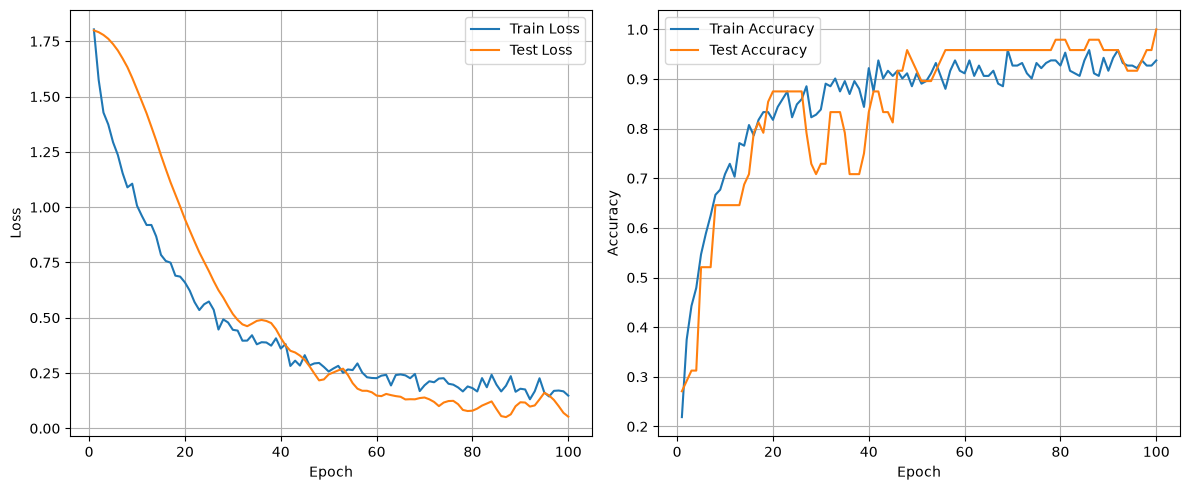

In [28]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, final_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=6, bias=True)
  )
)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

predictions = []

with torch.no_grad():
    for data in X_test:
        data = data.to(device)

        y_pred = model(data)
        prediction = y_pred.argmax(dim=-1).item()

        predictions.append(prediction)
        print(prediction)

ValueError: expected 2D or 3D input (got 1D input)

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

with torch.no_grad():
    # Train accuracy
    train_outputs = model(X_train.to(device))
    train_predicted = train_outputs.argmax(dim=1)
    train_labels = y_train.to(device).view(-1)

    train_accuracy = (train_predicted == train_labels).float().mean().item()

    # Test accuracy
    test_outputs = model(X_test.to(device))
    test_predicted = test_outputs.argmax(dim=1)
    test_labels = y_test.to(device).view(-1)

    test_accuracy = (test_predicted == test_labels).float().mean().item()

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.9948
Test Accuracy: 1.0000


In [32]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Model output:", model(X_test.to(device)).shape)
print("Train labels:", torch.unique(y_train))
print("Test labels:", torch.unique(y_test))

X_train: torch.Size([192, 30])
y_train: torch.Size([192])
X_test: torch.Size([48, 30])
y_test: torch.Size([48])
Model output: torch.Size([48, 6])
Train labels: tensor([0, 1, 2, 3, 4, 5], device='cuda:0')
Test labels: tensor([0, 1, 2, 3, 4, 5], device='cuda:0')


In [33]:
model.eval()

with torch.no_grad():
    train_output = model(X_train.to(device))
    train_pred = train_output.argmax(dim=1)
    train_acc = (train_pred == y_train.to(
        device).view(-1)).float().mean().item()

    test_output = model(X_test.to(device))
    test_pred = test_output.argmax(dim=1)
    test_acc = (test_pred == y_test.to(device).view(-1)).float().mean().item()

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9948
Test Accuracy: 1.0000


In [35]:
print("Actual test labels:   ", y_test.cpu().view(-1).tolist())
print("Predicted test labels:", test_pred.cpu().tolist())

Actual test labels:    [3, 5, 2, 5, 3, 2, 1, 4, 3, 3, 1, 2, 5, 2, 5, 4, 1, 0, 1, 0, 1, 3, 0, 2, 1, 0, 2, 3, 3, 0, 3, 3, 2, 4, 4, 1, 4, 4, 4, 1, 5, 1, 2, 3, 1, 5, 2, 0]
Predicted test labels: [3, 5, 2, 5, 3, 2, 1, 4, 3, 3, 1, 2, 5, 2, 5, 4, 1, 0, 1, 0, 1, 3, 0, 2, 1, 0, 2, 3, 3, 0, 3, 3, 2, 4, 4, 1, 4, 4, 4, 1, 5, 1, 2, 3, 1, 5, 2, 0]
